# Google Cloud CMIP6 Public Data: Basic Python Example

This notebooks shows how to query the catalog and load the data using python

In [1]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.8/318.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0
  Attempting uninstall: gcsfs
    Found existing installation: gcsfs 2025.3.0
    Uninstalling gcsfs-2025.3.0:
      Successful

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import gcsfs

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
plt.rcParams['figure.figsize'] = 12, 6

## Browse Catalog

The data catatalog is stored as a CSV file. Here we read it with Pandas.

In [4]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


The columns of the dataframe correspond to the CMI6 controlled vocabulary. A beginners' guide to these terms is available in [this document](https://docs.google.com/document/d/1yUx6jr9EdedCOLd--CPdTfGDwEwzPpCF6p1jRmqx-0Q).

Here we filter the data to find monthly surface air temperature for historical experiments.

In [5]:
df_ta = df.query("activity_id=='CMIP' & table_id == 'Amon' & variable_id == 'tas' & experiment_id == 'historical'")
df_ta

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
973,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r3i1p1f1,Amon,tas,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
1766,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r2i1p1f1,Amon,tas,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,NaN,20180701
8074,CMIP,NOAA-GFDL,GFDL-CM4,historical,r1i1p1f1,Amon,tas,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...,NaN,20180701
22185,CMIP,IPSL,IPSL-CM6A-LR,historical,r8i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,NaN,20180803
22298,CMIP,IPSL,IPSL-CM6A-LR,historical,r2i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,NaN,20180803
...,...,...,...,...,...,...,...,...,...,...,...
522952,CMIP,MRI,MRI-ESM2-0,historical,r7i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/MRI/MRI-ESM2-0/historica...,NaN,20210813
523274,CMIP,MRI,MRI-ESM2-0,historical,r6i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/MRI/MRI-ESM2-0/historica...,NaN,20210907
523712,CMIP,CMCC,CMCC-CM2-SR5,historical,r3i1p2f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/CMCC/CMCC-CM2-SR5/histor...,NaN,20211108
523721,CMIP,CMCC,CMCC-CM2-SR5,historical,r2i1p2f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/CMCC/CMCC-CM2-SR5/histor...,NaN,20211109


Now we do further filtering to find just the models from NCAR.

In [6]:
df_ta_ncar = df_ta.query('institution_id == "NCAR"')
df_ta_ncar

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
56049,CMIP,NCAR,CESM2-WACCM,historical,r2i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2-WACCM/histori...,NaN,20190227
56143,CMIP,NCAR,CESM2-WACCM,historical,r3i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2-WACCM/histori...,NaN,20190227
56326,CMIP,NCAR,CESM2-WACCM,historical,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2-WACCM/histori...,NaN,20190227
59875,CMIP,NCAR,CESM2,historical,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r1...,NaN,20190308
61655,CMIP,NCAR,CESM2,historical,r4i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r4...,NaN,20190308
61862,CMIP,NCAR,CESM2,historical,r5i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r5...,NaN,20190308
62691,CMIP,NCAR,CESM2,historical,r2i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r2...,NaN,20190308
63131,CMIP,NCAR,CESM2,historical,r3i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r3...,NaN,20190308
63266,CMIP,NCAR,CESM2,historical,r6i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r6...,NaN,20190308
64615,CMIP,NCAR,CESM2,historical,r8i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r8...,NaN,20190311


## Load Data

Now we will load a single store using gcsfs, zarr, and xarray.

In [7]:
# this only needs to be created once
gcs = gcsfs.GCSFileSystem(token='anon')

# get the path to a specific zarr store (the first one from the dataframe above)
zstore = df_ta_ncar.loc[59875].zstore

# create a mutable-mapping-style interface to the store
mapper = gcs.get_mapper(zstore)

# open it using xarray and zarr
ds = xr.open_zarr(mapper, consolidated=True)
ds

<xarray.Dataset> Size: 438MB
Dimensions:    (time: 1980, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * time       (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    lat_bnds   (lat, nbnd) float32 2kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    lon_bnds   (lon, nbnd) float32 2kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    time_bnds  (time, nbnd) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
Dimensions without coordinates: nbnd
Data variables:
    tas        (time, lat, lon) float32 438MB dask.array<chunksize=(600, 192, 288), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                15
    ...                     ...
    table_id:               Amon
    tracking_id:            hdl:21.14100/d9a7225a-49c3-4470-b7ab-a8180926f839
    variable_id:            tas
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r1i1p1f1
    status:                 2019-10-25;created;by nhn2@columbia.edu

Plot a map from a specific date.

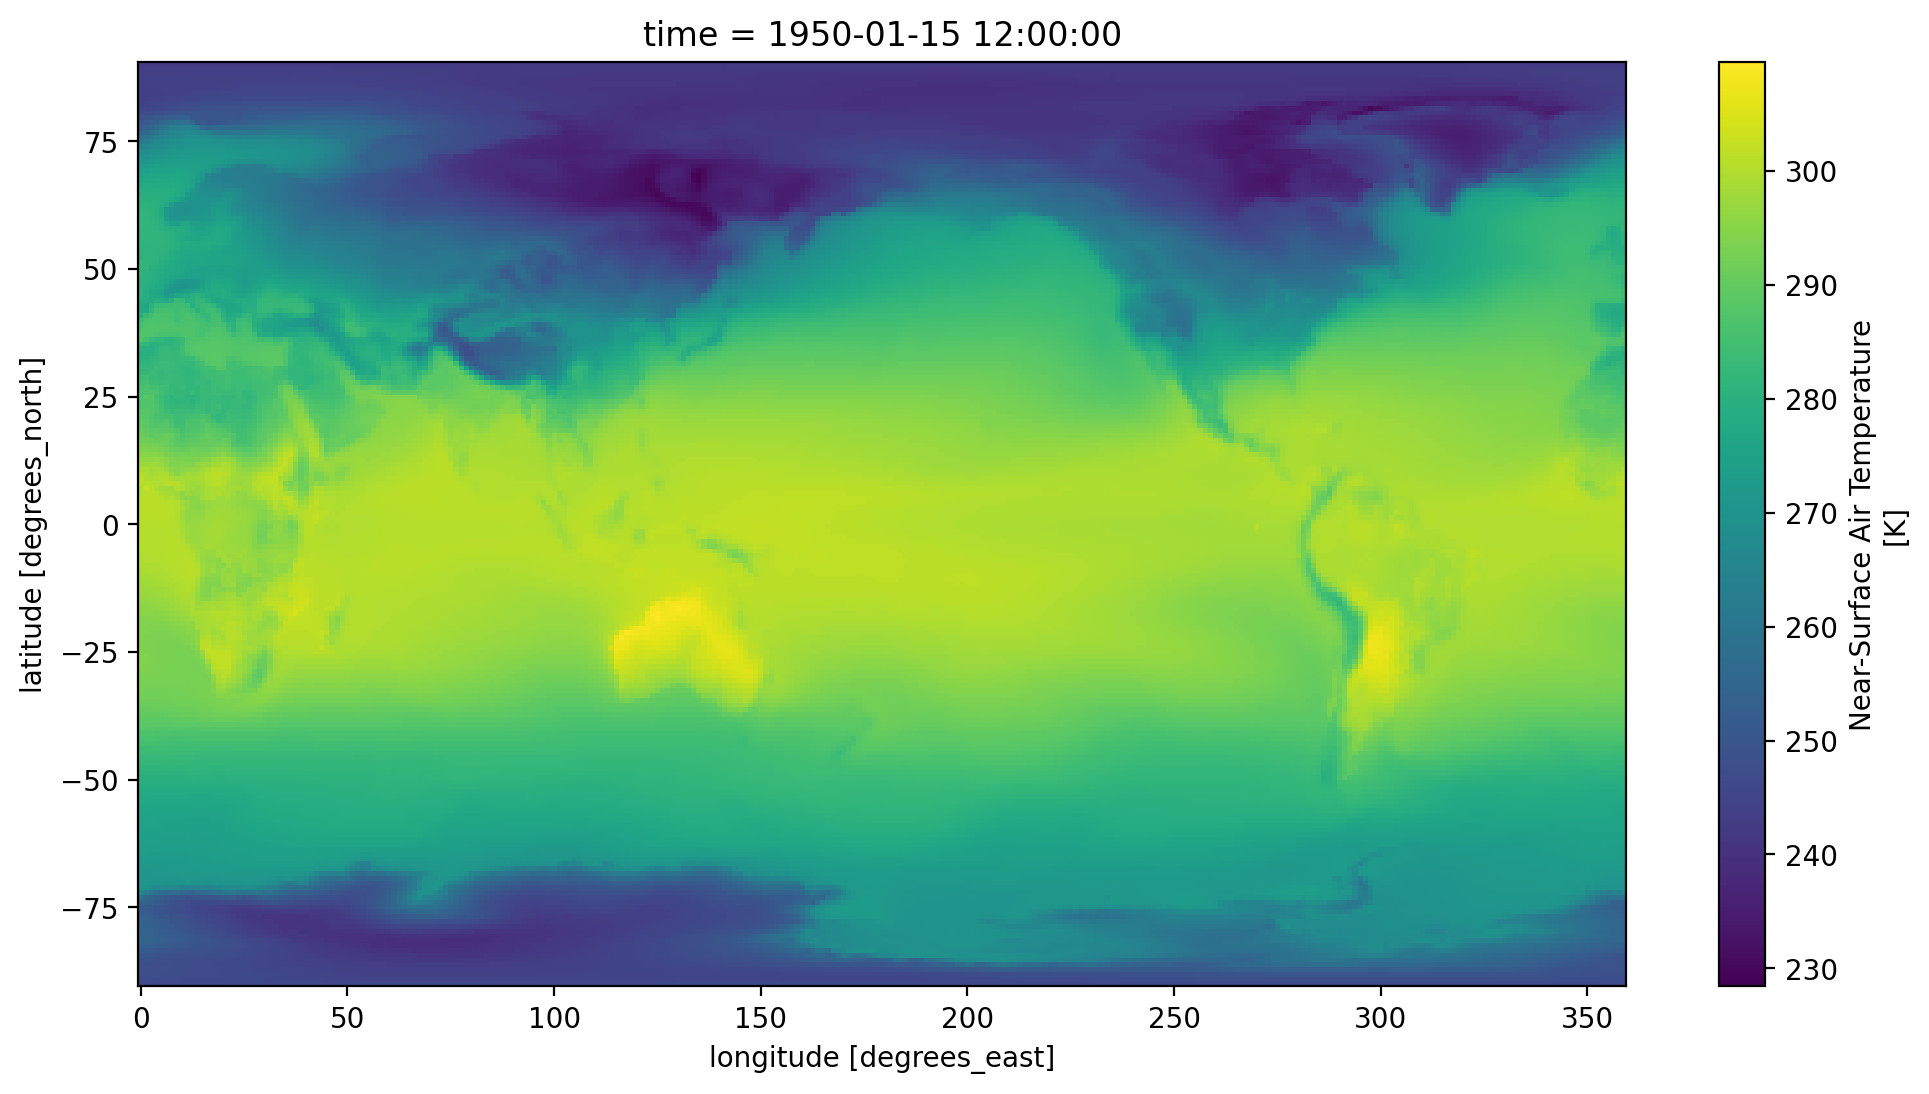

In [8]:
ds.tas.sel(time='1950-01').squeeze().plot()

Create a timeseries of global-average surface air temperature. For this we need the area weighting factor for each gridpoint.

In [9]:
df_area = df.query("variable_id == 'areacella' & source_id == 'CESM2'")
ds_area = xr.open_zarr(gcs.get_mapper(df_area.zstore.values[0]), consolidated=True)
ds_area

<xarray.Dataset> Size: 229kB
Dimensions:    (lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    lat_bnds   (lat, nbnd) float32 2kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    lon_bnds   (lon, nbnd) float32 2kB dask.array<chunksize=(288, 2), meta=np.ndarray>
Dimensions without coordinates: nbnd
Data variables:
    areacella  (lat, lon) float32 221kB dask.array<chunksize=(192, 288), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          no parent
    branch_time_in_child:   711385.0
    branch_time_in_parent:  0.0
    case_id:                38
    ...                     ...
    table_id:               fx
    tracking_id:            hdl:21.14100/23fa9dc3-4f8f-4943-b99b-58eb804c06f0
    variable_id:            areacella
    variant_info:           f.e21.FHIST_BGC.f09_f09_mg17.CMIP6-AMIP.001 
\n
\...
    variant_label:          r1i1p1f1
    status:                 2019-11-04;created;by nhn2@columbia.edu

In [10]:
total_area = ds_area.areacella.sum(dim=['lon', 'lat'])
ta_timeseries = (ds.tas * ds_area.areacella).sum(dim=['lon', 'lat']) / total_area
ta_timeseries

<xarray.DataArray (time: 1980)> Size: 8kB
dask.array<truediv, shape=(1980,), dtype=float32, chunksize=(600,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Attributes: (12/19)
    cell_measures:  area: areacella
    time:           time
    type:           real
    cell_methods:   area: sum
    comment:        Cell areas for any grid used to report atmospheric variab...
    description:    Cell areas for any grid used to report atmospheric variab...
    ...             ...
    standard_name:  cell_area
    time_label:     None
    time_title:     No temporal dimensions ... fixed field
    title:          Grid-Cell Area for Atmospheric Grid Variables
    units:          m2
    variable_id:    areacella

By default the data are loaded lazily, as Dask arrays. Here we trigger computation explicitly.

In [11]:
ta_timeseries.load()

<xarray.DataArray (time: 1980)> Size: 8kB
array([285.2367 , 285.49353, 286.10147, ..., 288.3483 , 287.31396,
       286.56613], dtype=float32)
Coordinates:
  * time     (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Attributes: (12/19)
    cell_measures:  area: areacella
    time:           time
    type:           real
    cell_methods:   area: sum
    comment:        Cell areas for any grid used to report atmospheric variab...
    description:    Cell areas for any grid used to report atmospheric variab...
    ...             ...
    standard_name:  cell_area
    time_label:     None
    time_title:     No temporal dimensions ... fixed field
    title:          Grid-Cell Area for Atmospheric Grid Variables
    units:          m2
    variable_id:    areacella

Text(0.5, 1.0, 'Global Mean Surface Air Temperature')

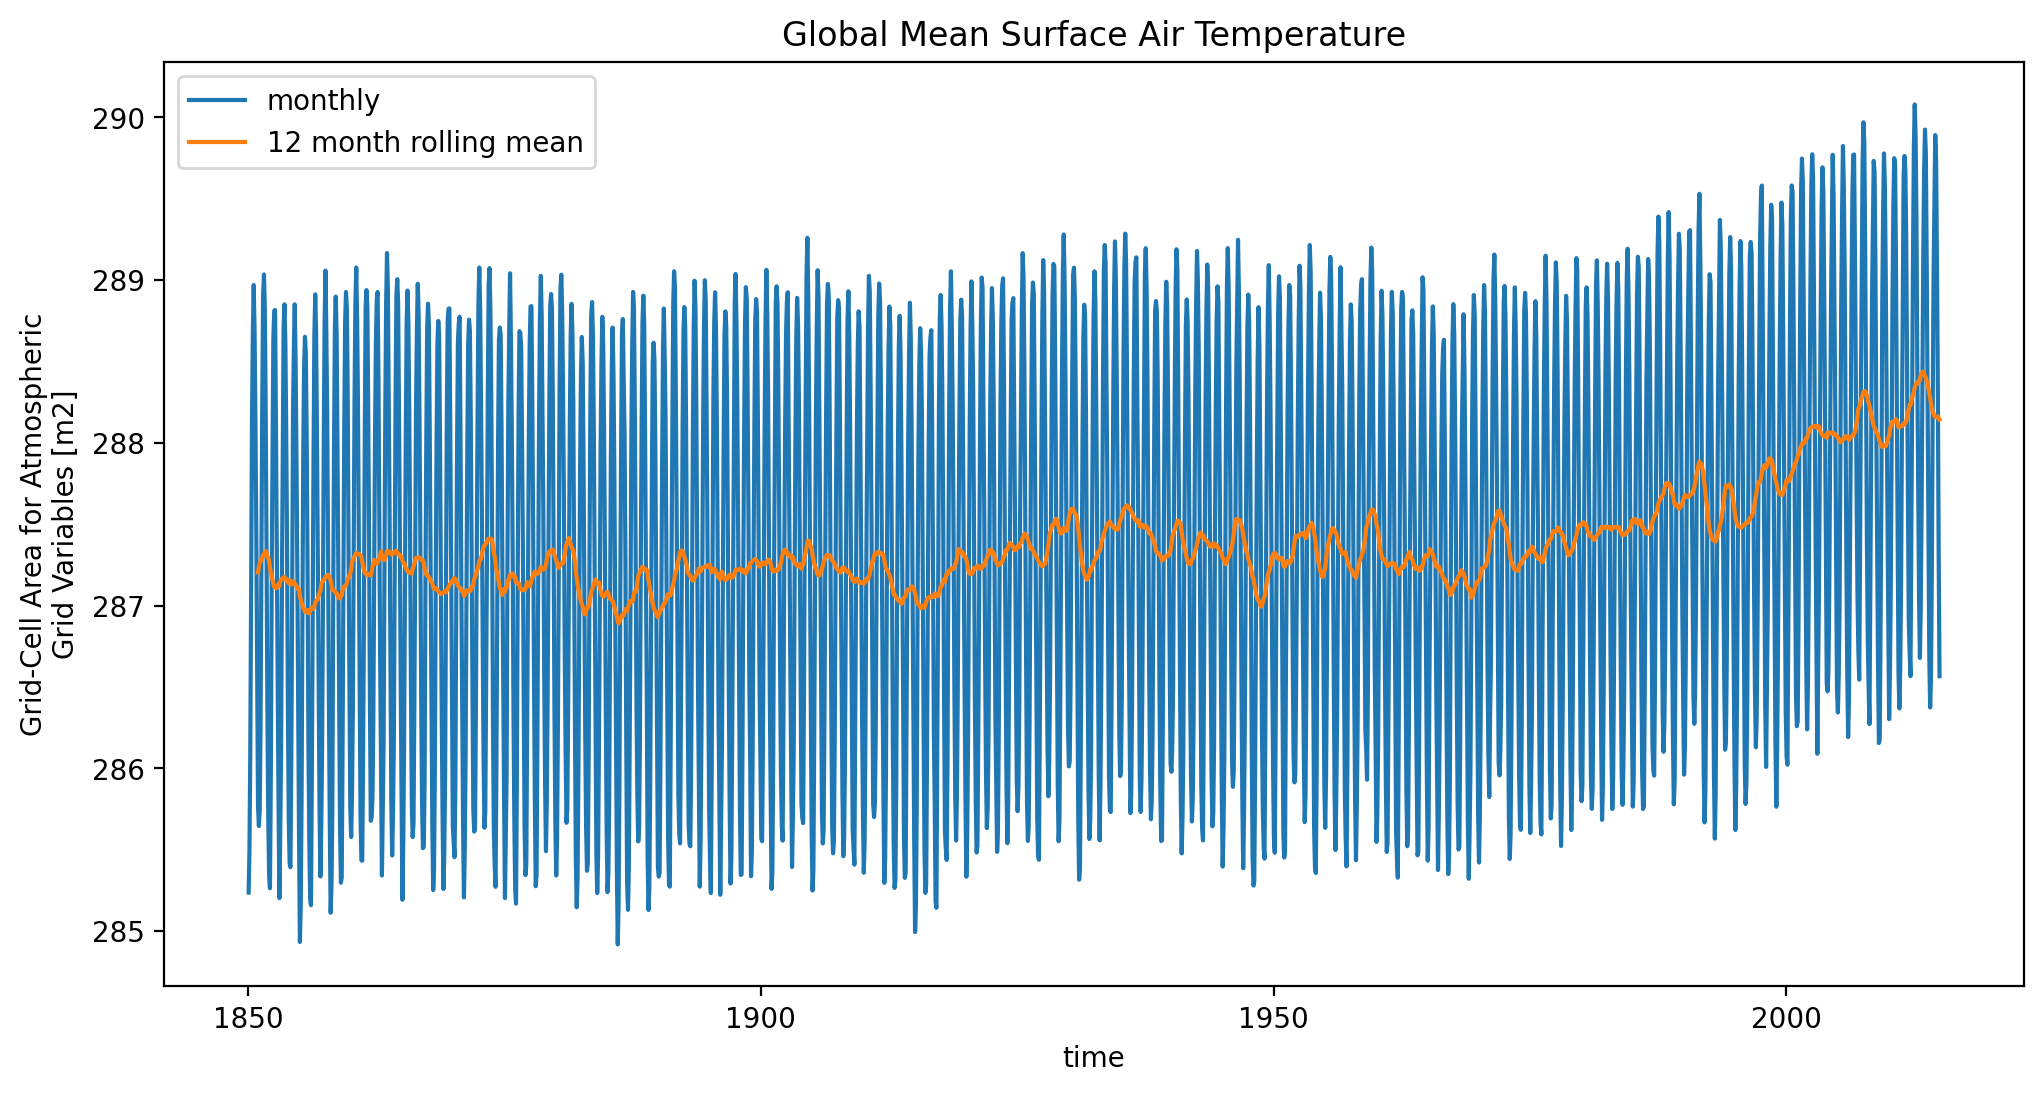

In [12]:
ta_timeseries.plot(label='monthly')
ta_timeseries.rolling(time=12).mean().plot(label='12 month rolling mean')
plt.legend()
plt.title('Global Mean Surface Air Temperature')

Or, we can select e.g. San Diego

In [13]:
sd_time_series = ds.tas.sel(lon=360-117.1611, lat=32.7157, method='nearest')

Text(0.5, 1.0, 'San Diego Surface Air Temperature')

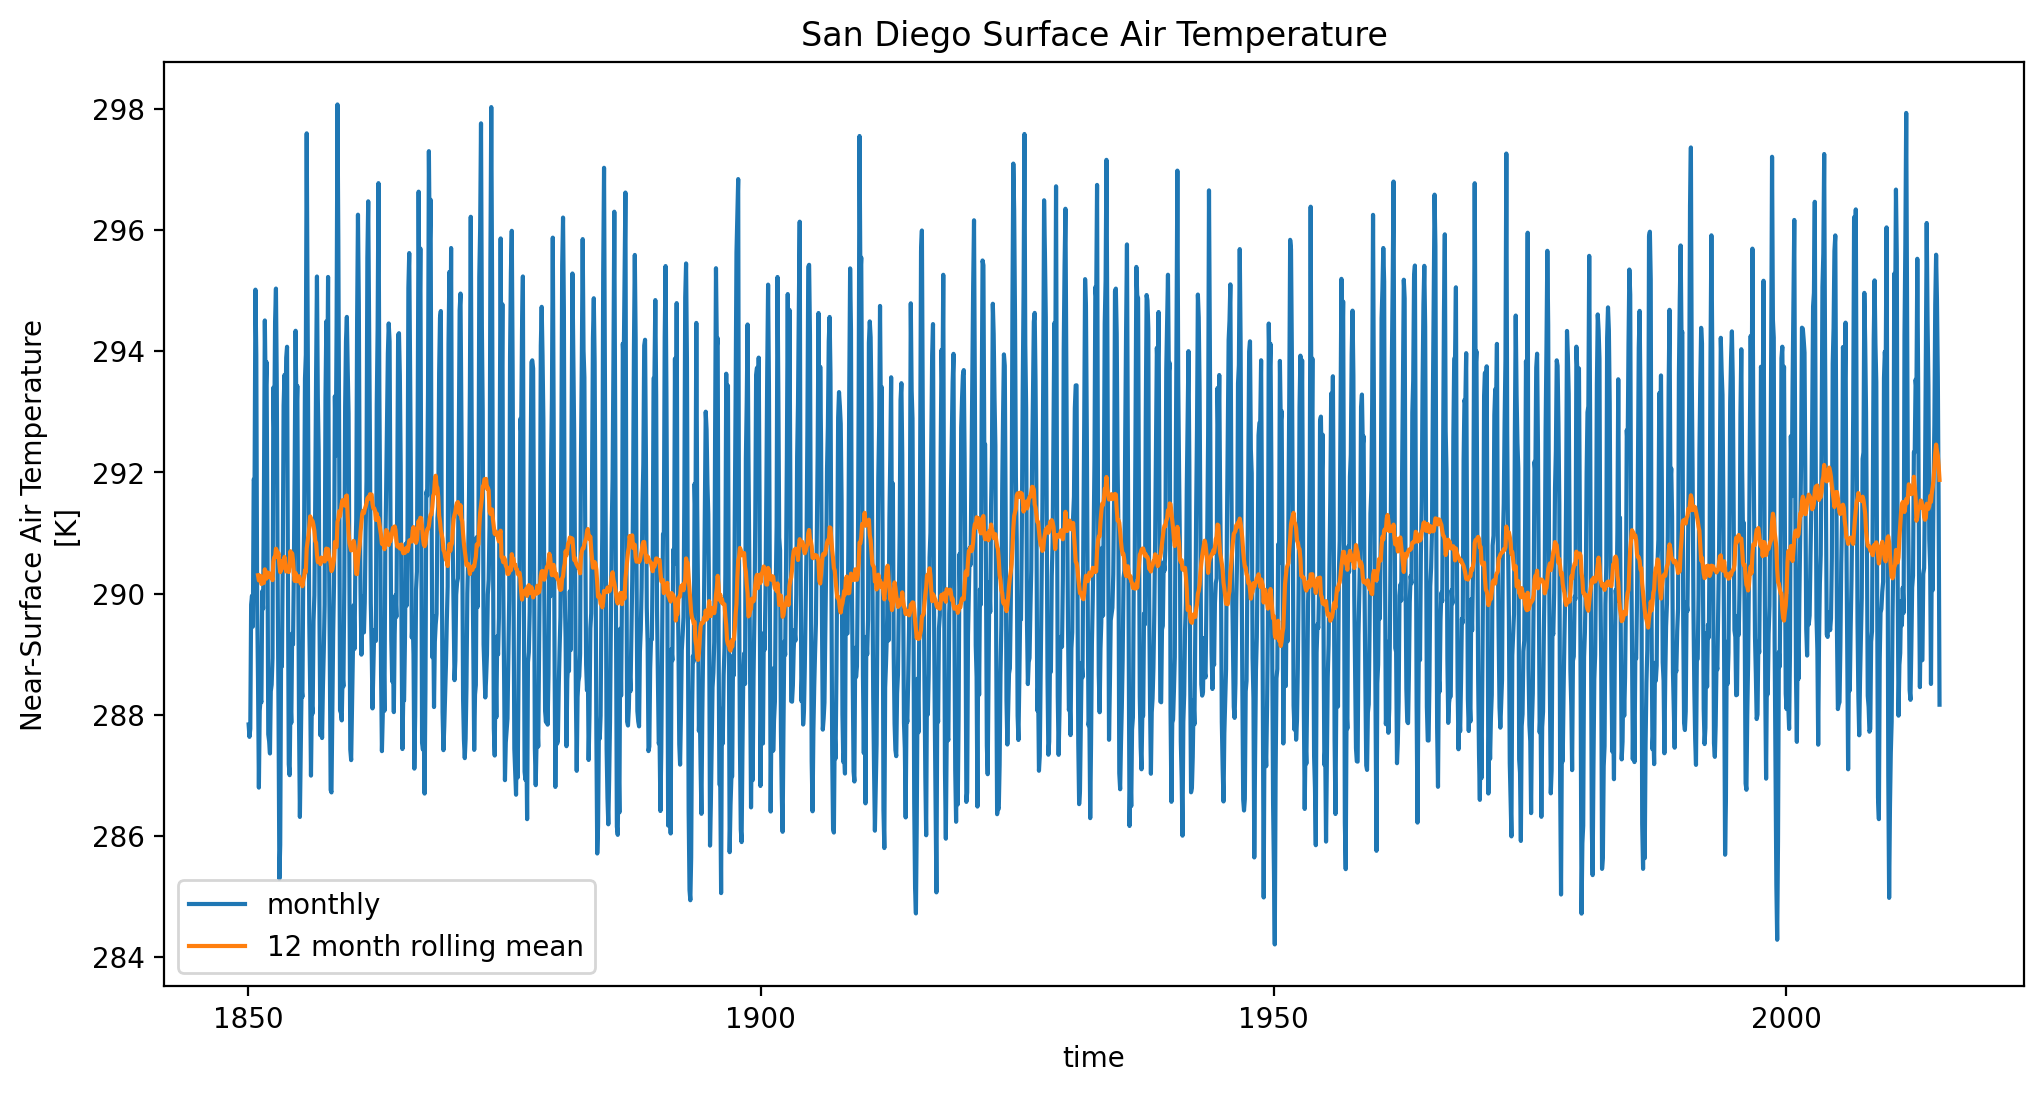

In [14]:
sd_time_series.plot(label='monthly')
sd_time_series.rolling(time=12).mean().plot(label='12 month rolling mean')
plt.legend()
plt.title('San Diego Surface Air Temperature')

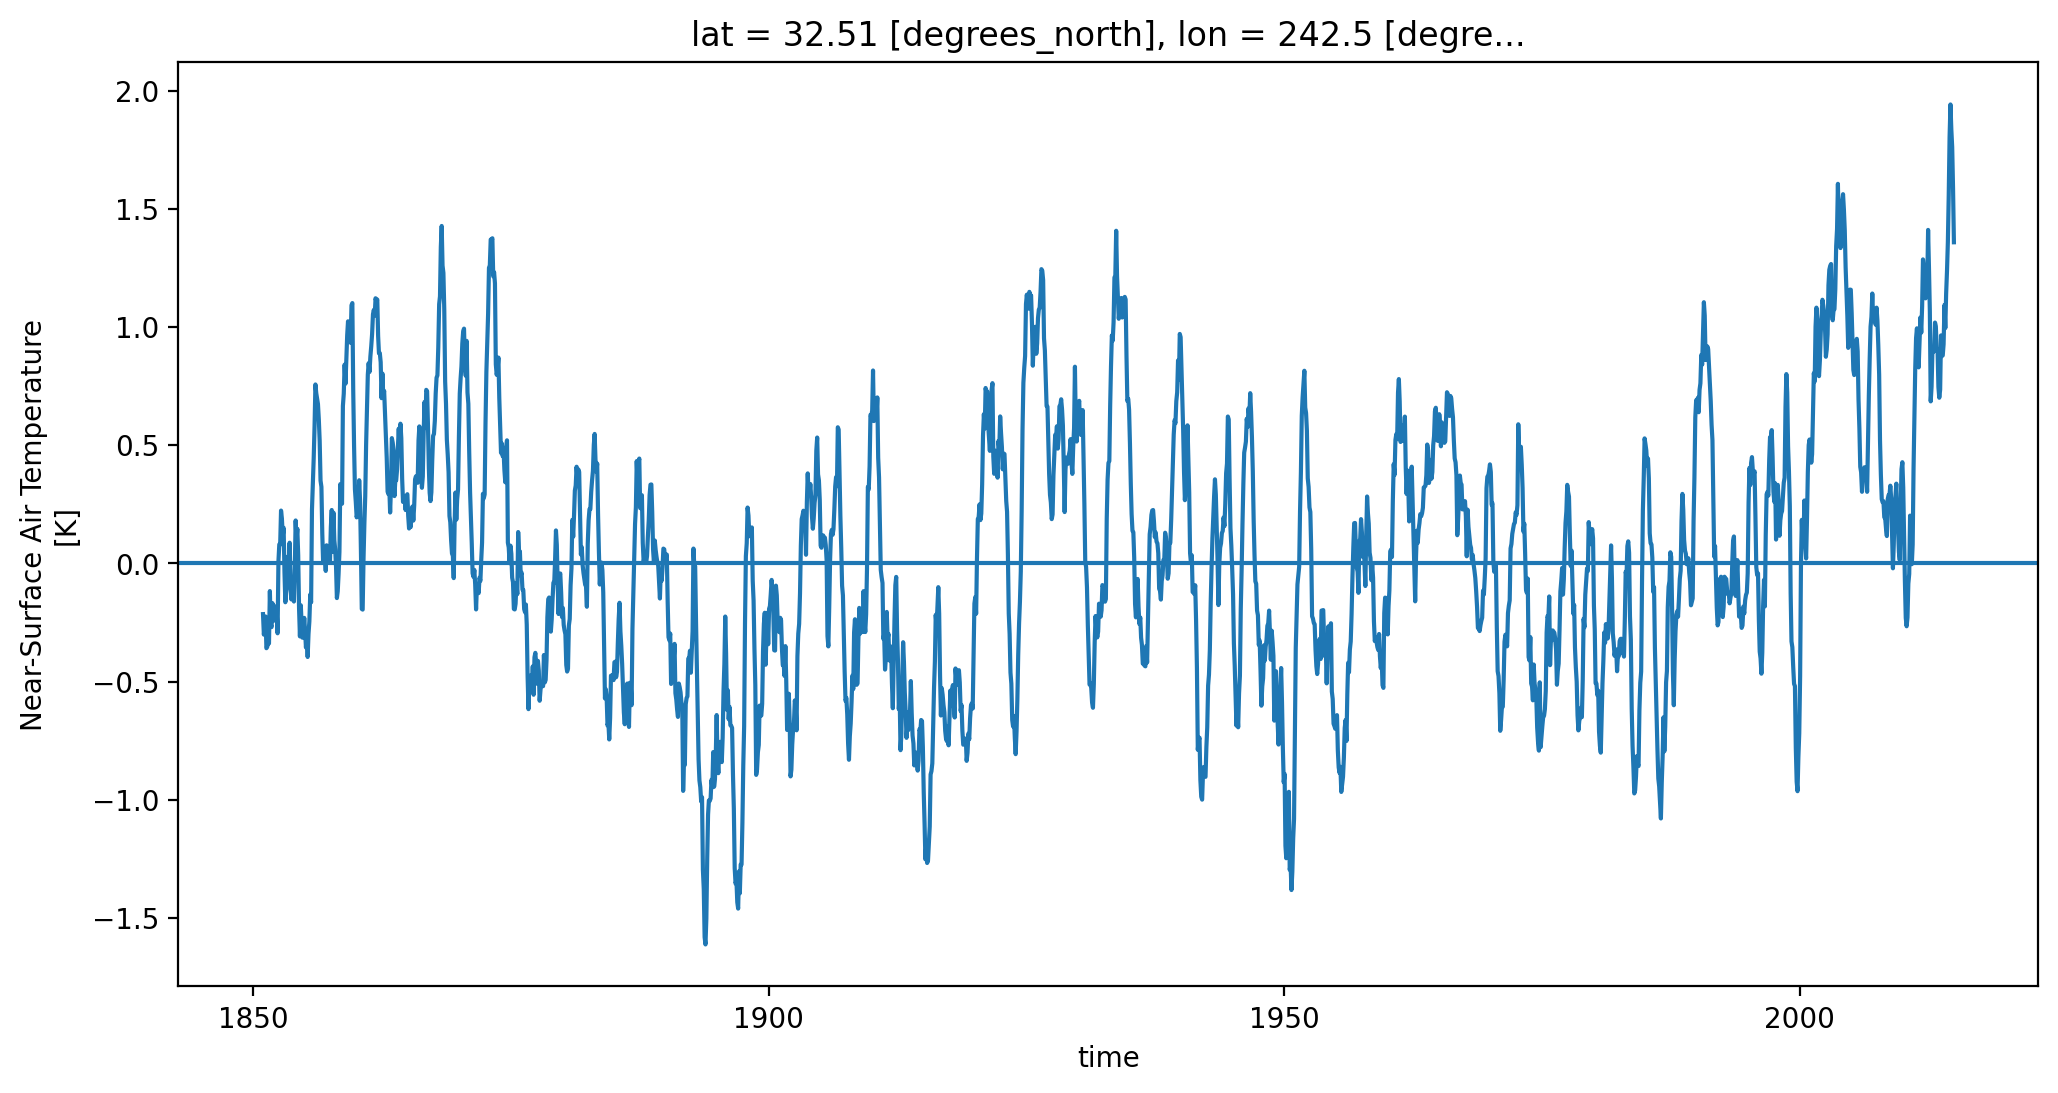

In [15]:
(sd_time_series.rolling(time=12).mean()-sd_time_series.sel(time=slice("1850","1900")).mean()).plot(label='12 month rolling mean')
plt.axhline(0.)

In [17]:
import pandas as pd
import xarray as xr
import gcsfs

# Load the Pangeo CMIP6 catalog
df_catalog = pd.read_csv(
    'https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv'
)

# Filter for surface temperature, two scenarios, one model
query = df_catalog[
    (df_catalog['variable_id'] == 'tas') &
    (df_catalog['experiment_id'].isin(['ssp245', 'ssp585'])) &
    (df_catalog['source_id'] == 'CESM2') &
    (df_catalog['table_id'] == 'Amon')
]

print(query[['experiment_id', 'source_id', 'zstore']].to_string())

       experiment_id source_id                                                                           zstore
444290        ssp245     CESM2  gs://cmip6/CMIP6/ScenarioMIP/NCAR/CESM2/ssp245/r10i1p1f1/Amon/tas/gn/v20200528/
444816        ssp585     CESM2  gs://cmip6/CMIP6/ScenarioMIP/NCAR/CESM2/ssp585/r11i1p1f1/Amon/tas/gn/v20200528/
444904        ssp585     CESM2   gs://cmip6/CMIP6/ScenarioMIP/NCAR/CESM2/ssp585/r4i1p1f1/Amon/tas/gn/v20200528/
445309        ssp245     CESM2   gs://cmip6/CMIP6/ScenarioMIP/NCAR/CESM2/ssp245/r4i1p1f1/Amon/tas/gn/v20200528/
445756        ssp585     CESM2  gs://cmip6/CMIP6/ScenarioMIP/NCAR/CESM2/ssp585/r10i1p1f1/Amon/tas/gn/v20200528/
445825        ssp245     CESM2  gs://cmip6/CMIP6/ScenarioMIP/NCAR/CESM2/ssp245/r11i1p1f1/Amon/tas/gn/v20200528/


In [19]:
fs = gcsfs.GCSFileSystem(token='anon')
results = []

for _, row in query.iterrows():
    store = fs.get_mapper(row['zstore'])
    ds = xr.open_zarr(store, consolidated=True)

    # Compute global mean temperature per month, then resample to yearly
    tas_mean = ds['tas'].mean(dim=['lat', 'lon'])
    tas_yearly = tas_mean.resample(time='1YE').mean()

    df = tas_yearly.to_dataframe().reset_index()
    df['scenario'] = row['experiment_id']

    # Fix: cftime doesn't support .dt accessor — extract year manually
    df['year'] = [t.year for t in df['time']]
    df['tas_celsius'] = df['tas'] - 273.15
    results.append(df[['year', 'scenario', 'tas_celsius']])

df_timeseries = pd.concat(results).reset_index(drop=True)
print(df_timeseries.head(10))

   year scenario  tas_celsius
0  2015   ssp245     5.937073
1  2016   ssp245     5.814911
2  2017   ssp245     5.797821
3  2018   ssp245     5.884888
4  2019   ssp245     5.730835
5  2020   ssp245     5.886902
6  2021   ssp245     5.905823
7  2022   ssp245     5.919678
8  2023   ssp245     6.222504
9  2024   ssp245     6.218658


In [21]:
spatial_results = []

for _, row in query.iterrows():
    store = fs.get_mapper(row['zstore'])
    ds = xr.open_zarr(store, consolidated=True)

    # Select future decades only, compute decadal mean spatial maps
    for decade_start in [2020, 2040, 2060, 2080]:
        decade_end = decade_start + 9
        tas_decade = ds['tas'].sel(
            time=slice(str(decade_start), str(decade_end))
        ).mean(dim='time')

        df = tas_decade.to_dataframe().reset_index()
        df['scenario'] = row['experiment_id']
        df['decade'] = decade_start
        df['tas_celsius'] = df['tas'] - 273.15
        spatial_results.append(df[['lat', 'lon', 'scenario', 'decade', 'tas_celsius']])

df_spatial = pd.concat(spatial_results).reset_index(drop=True)
print(df_spatial.head(10))

    lat    lon scenario  decade  tas_celsius
0 -90.0   0.00   ssp245    2020   -45.522263
1 -90.0   1.25   ssp245    2020   -45.522263
2 -90.0   2.50   ssp245    2020   -45.522263
3 -90.0   3.75   ssp245    2020   -45.522263
4 -90.0   5.00   ssp245    2020   -45.522263
5 -90.0   6.25   ssp245    2020   -45.522263
6 -90.0   7.50   ssp245    2020   -45.522263
7 -90.0   8.75   ssp245    2020   -45.522263
8 -90.0  10.00   ssp245    2020   -45.522247
9 -90.0  11.25   ssp245    2020   -45.522247


In [22]:
df_timeseries.to_csv('timeseries.csv', index=False)
df_spatial.to_csv('spatial.csv', index=False)
print("Done! timeseries.csv:", df_timeseries.shape)
print("Done! spatial.csv:", df_spatial.shape)

Done! timeseries.csv: (516, 3)
Done! spatial.csv: (1327104, 5)
